In [16]:
from cr_knee_fit import experiments
from cr_knee_fit.elements import Element
from cr_knee_fit.fit_data import Data, DataConfig, FluxRatioData
from cr_knee_fit.utils import R_GV_LABEL

In [17]:
import itertools

from matplotlib import pyplot as plt

from cr_knee_fit.fit_data import CRSpectrumData, SpectrumDataConfig
from cr_knee_fit.utils import legend_artist_line, legend_with_added_items

ignore = {experiments.lhaaso_epos, experiments.lhaaso_qgsjet}

ALL = experiments.DIRECT + experiments.INDIRECT
conf = DataConfig(
    spectra=[
        SpectrumDataConfig(exp, element)
        for exp, element in itertools.product(ALL, Element.regular())
        if exp not in ignore
    ]
    + [
        SpectrumDataConfig.allparticle(exp)
        for exp in ALL
        if exp is not experiments.dampe
        if exp not in ignore
    ],
    lnA=[experiments.lhaaso_sibyll, experiments.tale],
)

d = Data.load(conf, verbose=True)

✅ AMS-02 H
✅ AMS-02 He
✅ AMS-02 Li
✅ AMS-02 Be
✅ AMS-02 B
✅ AMS-02 C
✅ AMS-02 N
✅ AMS-02 O
✅ AMS-02 F
✅ AMS-02 Ne
❌ AMS-02 Na: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/AMS-02_Na_energy.txt not found.
✅ AMS-02 Mg
✅ AMS-02 Al
✅ AMS-02 Si
❌ AMS-02 P: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/AMS-02_P_energy.txt not found.
✅ AMS-02 S
❌ AMS-02 Cl: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/AMS-02_Cl_energy.txt not found.
❌ AMS-02 Ar: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/AMS-02_Ar_energy.txt not found.
❌ AMS-02 K: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/AMS-02_K_energy.txt not found.
❌ AMS-02 Ca: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/AMS-02_Ca_energy.txt not found.
❌ AMS-02 Sc: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/AMS-02_Sc_energy.txt not found.
❌ AMS-02 Ti: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/AMS-02_Ti_energy.txt not found.
❌ AMS-02 V: /home/nj-vs-vh/

❌ LHAASO (S) B: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/LHAASO_SIBYLL-23_B_energy.txt not found.
❌ LHAASO (S) C: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/LHAASO_SIBYLL-23_C_energy.txt not found.
❌ LHAASO (S) N: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/LHAASO_SIBYLL-23_N_energy.txt not found.
❌ LHAASO (S) O: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/LHAASO_SIBYLL-23_O_energy.txt not found.
❌ LHAASO (S) F: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/LHAASO_SIBYLL-23_F_energy.txt not found.
❌ LHAASO (S) Ne: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/LHAASO_SIBYLL-23_Ne_energy.txt not found.
❌ LHAASO (S) Na: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/LHAASO_SIBYLL-23_Na_energy.txt not found.
❌ LHAASO (S) Mg: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/LHAASO_SIBYLL-23_Mg_energy.txt not found.
❌ LHAASO (S) Al: /home/nj-vs-vh/Documents/Science/cr-knee-fit/data/output/LHAASO_S

In [18]:
import numpy as np

from cr_knee_fit.fit_data import GenericExperimentData


def load_gamma_spectrum(fname: str, custom_label: str):
    E_TeV, F, Fstat, Fsyst = np.loadtxt(fname, unpack=True)
    Fconv = 1e-3 * 1e4  # TeV^-1 cm^-2 -> GeV^-1 m^-2

    return CRSpectrumData(
        d=GenericExperimentData(
            x=E_TeV * 1e3,
            y=F * Fconv,
            err_stat=np.vstack((Fstat, Fstat)).T * Fconv,
            err_syst=np.vstack((Fsyst, Fsyst)).T * Fconv,
            experiment=experiments.lhaaso_sibyll,
            custom_label=custom_label,
        ),
        spec="gamma",
        quantity="E",
    )

In [19]:
gamma_outer = load_gamma_spectrum("../data/lake/LHAASO_outerGalaxy.txt", " (outer)")
gamma_inner = load_gamma_spectrum("../data/lake/LHAASO_innerGalaxy.txt", " (inner)")

d.spectra.extend((gamma_inner, gamma_outer))

Spectra:
AMS-02
    AMS-02 H: 72 points from 1.1e+00 to 1.4e+03 GeV; total relative error from 0.88% to 4.92%
    AMS-02 He: 68 points from 4.1e+00 to 4.6e+03 GeV; total relative error from 1.28% to 7.97%
    AMS-02 Li: 67 points from 6.1e+00 to 6.1e+03 GeV; total relative error from 2.59% to 20.81%
    AMS-02 Be: 67 points from 8.1e+00 to 8.1e+03 GeV; total relative error from 2.75% to 39.32%
    AMS-02 B: 66 points from 1.1e+01 to 1.0e+04 GeV; total relative error from 2.39% to 20.39%
    AMS-02 C: 68 points from 1.2e+01 to 1.4e+04 GeV; total relative error from 2.27% to 11.30%
    AMS-02 N: 66 points from 1.6e+01 to 1.4e+04 GeV; total relative error from 3.13% to 14.02%
    AMS-02 F: 48 points from 2.0e+01 to 1.7e+04 GeV; total relative error from 3.38% to 75.55%
    AMS-02 Ne: 48 points from 2.3e+01 to 1.9e+04 GeV; total relative error from 3.42% to 12.77%
    AMS-02 O: 67 points from 1.8e+01 to 1.9e+04 GeV; total relative error from 2.67% to 11.72%
    AMS-02 Mg: 66 points from 2.

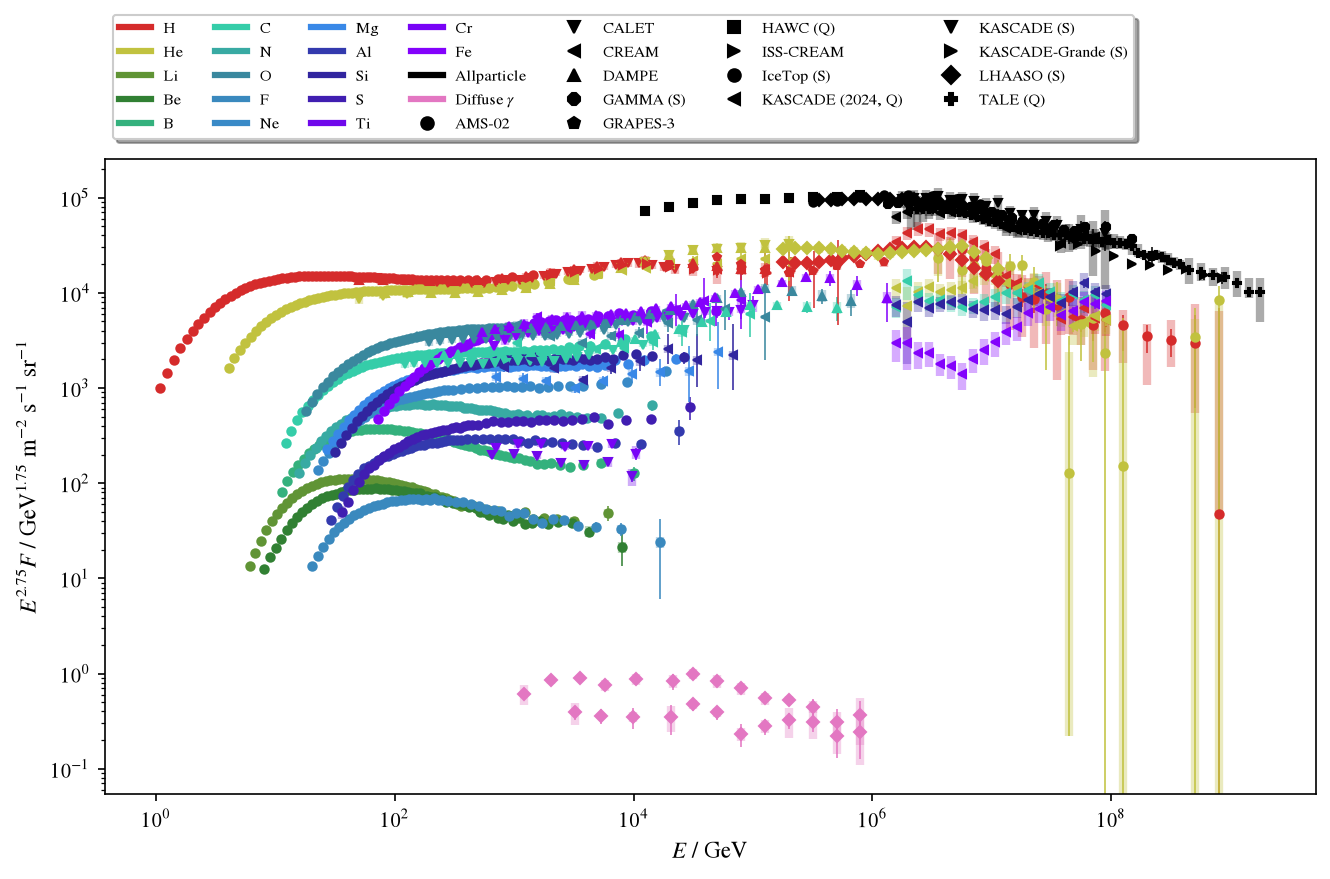

In [20]:
from cr_knee_fit.plotting import ALL_PARTICLE_COLOR

fig, ax = plt.subplots(figsize=(9, 6))
d.plot_spectra(describe=True, scale=2.75, is_fitted=True, ax=ax)
# ax.legend()
legend_with_added_items(
    ax,
    [(legend_artist_line(el.color, linewidth=3), el.name) for el in d.elements()]
    + [
        (legend_artist_line(ALL_PARTICLE_COLOR, linewidth=3), "Allparticle"),
        (legend_artist_line("tab:pink", linewidth=3), "Diffuse $\\gamma$"),
    ]
    + [(exp.legend_artist(True), exp.name) for exp in sorted(d.experiments(spectra_only=True))],
    fontsize="x-small",
    bbox_to_anchor=(0.00, 1.02, 1.0, 0.0),
    loc="lower left",
    fancybox=True,
    shadow=True,
    ncol=7,
)
fig.tight_layout()

lnA data:
    LHAASO (S) <lnA>: 20 points from 3.5e+05 to 2.8e+07 GeV; total relative error from 5.21% to 9.42%
    TALE (Q) <lnA>: 17 points from 3.5e+07 to 2.5e+09 GeV; total relative error from 15.08% to 208.50%


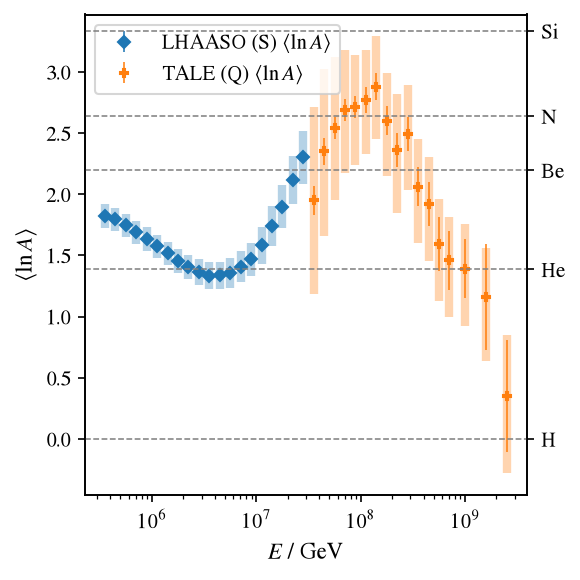

In [21]:
from cr_knee_fit.utils import add_elements_lnA_secondary_axis

fig, ax = plt.subplots(figsize=(4, 4))
d.plot_lnA(describe=True, is_fitted=True, ax=ax)
add_elements_lnA_secondary_axis(ax)
leg = ax.legend()
leg.set_zorder(100)
fig.tight_layout()

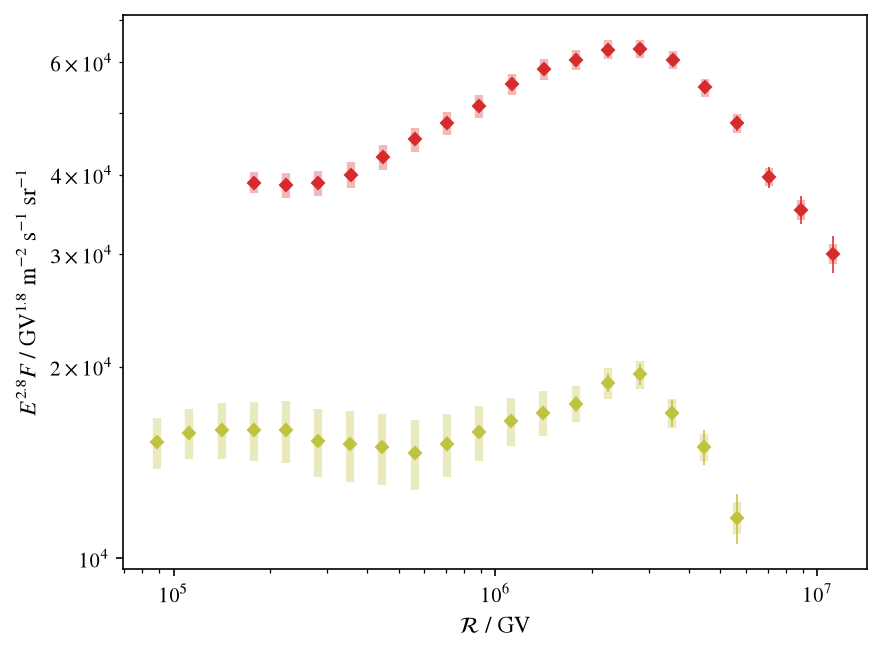

In [22]:
lhaaso = experiments.lhaaso_sibyll

p = CRSpectrumData.load(lhaaso, Element.H)
He = CRSpectrumData.load(lhaaso, Element.He)

fig, ax = plt.subplots()
p.to_quantity("R").plot(scale=2.8, ax=ax)
He.to_quantity("R").plot(scale=2.8, ax=ax)
ax.set_xscale("log")
ax.set_yscale("log")

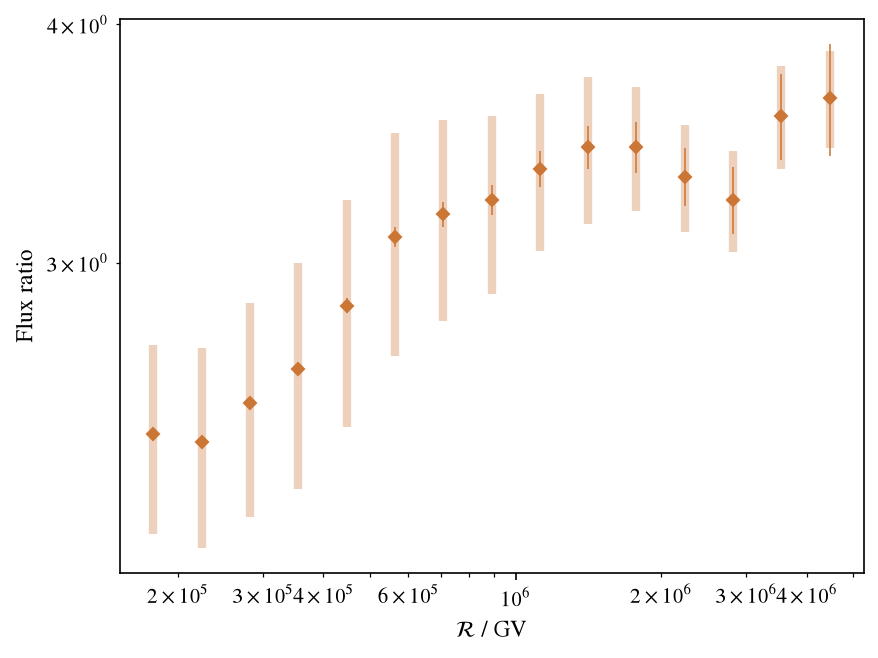

In [23]:
lhaaso = FluxRatioData.from_fluxes(p, He, quantity="R")
ax = lhaaso.plot()
ax.set_xscale("log")
ax.set_yscale("log")

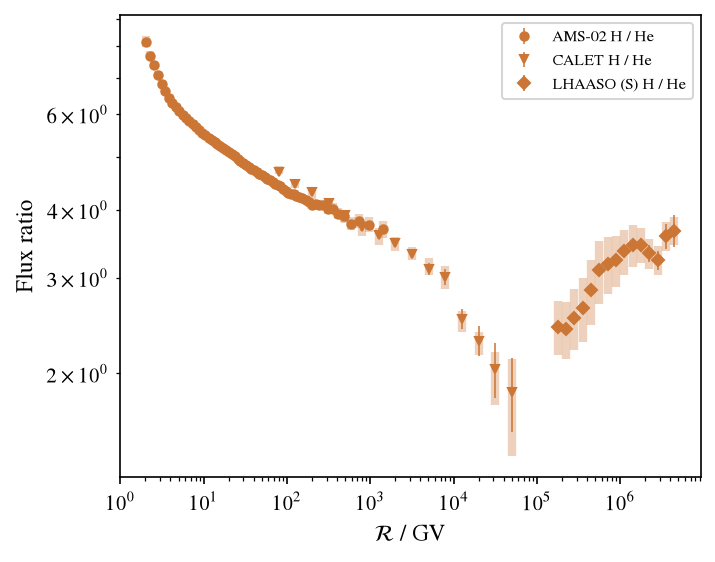

In [ ]:
p_over_He = Element.H / Element.He
ams = FluxRatioData.load(experiments.ams02, p_over_He)
calet = FluxRatioData.load(experiments.calet, p_over_He)

d = Data(config=DataConfig(), flux_ratios=[ams, calet])
d.flux_ratios.append(lhaaso)

fig, ax = plt.subplots(figsize=(5, 4))
for fr in d.flux_ratios:
    fr.plot_in_R(ax=ax, is_fitted=True)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(R_GV_LABEL)
ax.set_ylabel("Flux ratio")
# legend_with_added_items()
ax.legend(fontsize="x-small")